[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anicka-net/nla-at-home/blob/main/notebooks/04_reading_between_the_lines.ipynb)

# 04 · Reading Between the Lines

### HAAISS workshop — bonus techniques

You can read a mind (NB1), inject by hand (NB2), and check faithfulness (NB3). This notebook is a toolbox of *ways to interrogate* an activation — each cell teaches one interpretability move you can reuse on any model.

Same setup as NB1 (Qwen 2.5 7B, T4). Run the setup cells, then any section in any order.

## Setup

In [1]:
!pip install -q -U transformers peft accelerate bitsandbytes matplotlib

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE       = "Qwen/Qwen2.5-7B-Instruct"          # the model whose mind we read
AV_ADAPTER = "anicka/nla-qwen2.5-7b-L20-av-v2"    # the "verbalizer" (activation -> English)
LAYER      = 20                                   # single-layer NLA lives at Qwen layer 20
DEPTH_PCT  = 71                                   # <-- NOT cosmetic. The adapter was TRAINED
                                                  #     at 71% depth (layer 20 of 28). This
                                                  #     number is a CONDITIONING INPUT to the
                                                  #     verbalizer. Notebook 02 lets you feel
                                                  #     what happens when you lie about it.
INJECT_CHAR  = "\u320e"                          # the placeholder token we overwrite: ㈎
INJECT_SCALE = 150.0                              # we normalize the activation's L2 norm TO this

In [3]:
device = "cuda"
assert torch.cuda.is_available(), "Runtime -> Change runtime type -> T4 GPU"

# 4-bit so a 7B model + adapters fit a free-Colab T4 (16 GB). fp16 compute:
# the GRPO-sharpened adapter is numerically sensitive, and fp16 on CUDA is a
# tested-safe path (bf16 on Apple MPS collapses it; not our case here).
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16)

tok  = AutoTokenizer.from_pretrained(BASE)
base = AutoModelForCausalLM.from_pretrained(BASE, quantization_config=bnb,
                                            device_map={"": 0})
model = PeftModel.from_pretrained(base, AV_ADAPTER).eval()   # adapter name = "default"

inject_id = tok.encode(INJECT_CHAR, add_special_tokens=False)
assert len(inject_id) == 1, f"injection char must be ONE token, got {inject_id}"
inject_id = inject_id[0]
print("loaded — base + AV adapter on", next(model.parameters()).device)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

loaded — base + AV adapter on cuda:0


In [4]:
def get_layers(m):
    """Reach the transformer block list through the PEFT + CausalLM wrappers."""
    b = m.base_model.model if hasattr(m, "base_model") else m
    inner = b.model if hasattr(b, "model") else b
    return inner.layers

def read_activation(prompt, layer=LAYER, max_new_tokens=128):
    """Run the model on `prompt` and grab the residual-stream vector at `layer`,
    at the last prompt token (the position that decides the next word)."""
    chat = tok.apply_chat_template([{"role": "user", "content": prompt}],
                                   tokenize=False, add_generation_prompt=True)
    inp = tok(chat, return_tensors="pt").to(device)

    grab = {}
    def hook(mod, inpt, out):
        h = out[0] if isinstance(out, tuple) else out
        if "h" not in grab:                 # FIRST forward pass only — otherwise
            grab["h"] = h[:, -1, :].detach() # every generated token overwrites it
    handle = get_layers(model)[layer].register_forward_hook(hook)
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=max_new_tokens, do_sample=False,
                             pad_token_id=tok.eos_token_id)
    handle.remove()
    reply = tok.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)
    return grab["h"].squeeze(0), reply

def normalize_to(v, scale=INJECT_SCALE):
    """Rescale v so its L2 norm equals `scale`. NOT v * scale — see notebook 02."""
    n = v.float().norm().clamp_min(1e-12)
    return v * (scale / n)

def av_prompt(depth_pct):
    return (
        "You are a meticulous AI researcher conducting an important investigation "
        "into activation vectors from a language model. Your overall task is to "
        "describe the semantic content of that activation vector.\n\n"
        "We will pass the vector enclosed in <concept> tags into your context, "
        "along with the network depth where it was extracted. "
        "You must then produce an explanation for the vector, enclosed within "
        "<explanation> tags. The explanation consists of 2-3 text snippets "
        "describing that vector.\n\n"
        f"Here is the vector from depth {depth_pct}% of the network:\n\n"
        f"<concept>{INJECT_CHAR}</concept>\n\n"
        "Please provide an explanation.\n\n"
        "<explanation>")

def describe(activation, depth=DEPTH_PCT, max_new_tokens=120, scale_fn=normalize_to):
    """The whole NLA read: build the prompt, overwrite the placeholder token's
    embedding with the (rescaled) activation, let the model narrate."""
    ids = tok.encode(av_prompt(depth), add_special_tokens=True)
    pos = ids.index(inject_id)
    emb = model.get_input_embeddings()(torch.tensor([ids], device=device)).clone()
    emb[0, pos, :] = scale_fn(activation.to(emb.dtype))
    with torch.no_grad():
        out = model.generate(inputs_embeds=emb, max_new_tokens=max_new_tokens,
                             do_sample=False, pad_token_id=tok.eos_token_id)
    seq = out[0]
    gen = seq[len(ids):] if seq.shape[0] > len(ids) else seq  # embeds path returns new-only
    return tok.decode(gen, skip_special_tokens=True).split("</explanation>")[0].strip()

In [5]:
def grab_activation(prompt, layer=LAYER):
    """Forward-only (no generation) — fast, for building means/banks."""
    chat = tok.apply_chat_template([{"role": "user", "content": prompt}],
                                   tokenize=False, add_generation_prompt=True)
    inp = tok(chat, return_tensors="pt").to(device)
    grab = {}
    def hook(m, i, o):
        h = o[0] if isinstance(o, tuple) else o
        grab["h"] = h[:, -1, :].detach()
    hd = get_layers(model)[layer].register_forward_hook(hook)
    with torch.no_grad():
        model(**inp)
    hd.remove()
    return grab["h"].squeeze(0)

def logit_lens(prompt, layer=LAYER, k=8):
    """The classic tool: project the layer-`layer` residual through the model's
    own final norm + unembedding to read it as vocabulary tokens."""
    chat = tok.apply_chat_template([{"role": "user", "content": prompt}],
                                   tokenize=False, add_generation_prompt=True)
    inp = tok(chat, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inp, output_hidden_states=True)
    h = out.hidden_states[layer + 1][0, -1]
    base = model.base_model.model if hasattr(model, "base_model") else model
    inner = base.model if hasattr(base, "model") else base
    logits = model.get_output_embeddings()(inner.norm(h))
    return [tok.decode([t]) for t in logits.topk(k).indices.tolist()]

## A · What's *special* about this activation? (deviation from the mean)

A single activation is hard to read in isolation. The trick: compare it to the **average** activation. The mean is what the model does *generically*; the **deviation** is the actual content of this input. (This is also why *centering* matters — the signal is the deviation, not the raw vector.)

In [6]:
# build a "generic" mean over a handful of unrelated prompts
bank_prompts = ["What is 2+2?", "Describe a sunset.", "Write a for loop.",
                "Who was Napoleon?", "How do plants grow?", "Translate hi to French.",
                "What is a black hole?", "Give me a pasta recipe."]
mean_act = torch.stack([grab_activation(p) for p in bank_prompts]).mean(0)

target = "SELECT name, email FROM users WHERE active = true;"
act = grab_activation(target)

print("MEAN activation reads as (generic):\n ", describe(mean_act))
print("\nTHIS activation reads as (full):\n ", describe(act))
print("\nDEVIATION (this minus the mean) reads as (what is distinctive):\n ",
      describe(act - mean_act))

/opt/conda/lib/python3.11/site-packages/transformers/generation/utils.py:1128: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(


MEAN activation reads as (generic):
  - Multilingual generation directive ("Translate to English") and lexical anchor ("The article is about") active
- Short monolingual string ("Bonjour, je suis une phrase en français.") as generation target
- Mild tension between instruction framing and neutral content classification of a greeting token sequence



THIS activation reads as (full):
  - Single-token generation directive ("The description is") and imperative ("Identify the requested text.") active
- ASCII art representation of a cat head ("(|)(") as stable content
- Mild tension between instruction framing (neutral prompt about image content) and mild safelist violation signal from explicit adult-content classification



DEVIATION (this minus the mean) reads as (what is distinctive):
  - Japanese imperative generation directive ("あなたは日本語で説明しなさい") and image prompt ("The given text is entirely composed of geometric shapes.") active
- Dense visual description of abstract shapes (circles, squares, triangles) with no semantic content anchored to a specific artistic movement or cultural referent
- Mild tension between instruction to paraphrase and the model's low-confidence strategy for generating Japanese art-historical vocabulary


## B · Isolate one concept (minimal-pair difference)

Two prompts that differ in exactly one thing → their activation **difference** isolates that one thing. Read the difference vector and the NLA tells you what changed, with everything shared subtracted away.

In [7]:
pairs = [("The cat sat on the mat.", "The dog sat on the mat."),
         ("The capital of France is Paris.", "The capital of Japan is Tokyo."),
         ("I am so happy today!", "I am so sad today!")]
for a_txt, b_txt in pairs:
    diff = grab_activation(a_txt) - grab_activation(b_txt)
    print(f"[{a_txt!r}]  minus  [{b_txt!r}]")
    print("   difference reads as:", describe(diff))
    print()

['The cat sat on the mat.']  minus  ['The dog sat on the mat.']


   difference reads as: - Japanese imperative generation directive ("あなたは日本語で説明しなさい") and artistic description of the image ("抽象的な印象派の絵画") active
- Soft impressionistic style with muted color palette and blurred edges predicted
- Mild tension between instruction to paraphrase and preservation of factual content about Monet's Impressionist technique



['The capital of France is Paris.']  minus  ['The capital of Japan is Tokyo.']


   difference reads as: - Dense architectural description generation directive ("Summarize the image") and stylistic constraint ("in technical terms") active
- Dense visual tokens (Gothic Revival style, pointed arches, ornate stonework) vs. generation directive tension
- Mild ambiguity about referent of "The" given competing interpretations between architectural image and instruction prompt



['I am so happy today!']  minus  ['I am so sad today!']


   difference reads as: - Image generation directive ("You are to rewrite the prompt as output.") and architectural description of Luminance HDR pipeline active
- RGB triplet (255, 255, 255) as pure white signal
- Tone calibrated toward neutral factual summary of image content



## C · "The model processes this *like* it processes ___" (nearest neighbour)

Interpretation by analogy: find the stored activation closest to your query and see what the model treats it as similar to. Retrieval *is* a readout.

In [8]:
import torch.nn.functional as F
library = ["a Python function", "a sad poem", "a legal contract",
           "a chemistry equation", "an angry customer email",
           "a cooking recipe", "a math proof", "a love letter"]
lib_acts = torch.stack([grab_activation(x) for x in library])

query = "def merge_sort(arr): return arr if len(arr)<2 else merge(...)"
q = grab_activation(query)
sims = F.cosine_similarity(q.float().cpu().unsqueeze(0), lib_acts.float().cpu())
best = sims.argmax().item()
print(f"query: {query!r}")
print(f"nearest stored concept: {library[best]!r}  (cos {sims[best]:.2f})")
print("query readout    :", describe(q))
print("neighbour readout:", describe(lib_acts[best]))

query: 'def merge_sort(arr): return arr if len(arr)<2 else merge(...)'
nearest stored concept: 'a Python function'  (cos 0.75)


query readout    : - ASCII art generation directive ("Generate") and incomplete string ("H") active
- Mild tension between truncated instruction and empty output generation
- Predicting continuation of fragment as opening character of HTML tag sequence for a non-breaking space (`&nbsp;`)


neighbour readout: - Short text generation directive ("Give me") and prompt token ("Portuguese.") active
- Strong generation of neutral placeholder ("…") due to truncation of actual text content
- Mild tension between instruction to preserve original formatting and inability to decode Cyrillic script


## D · NLA vs the logit lens (two interpretability tools, side by side)

The **logit lens** reads a hidden state by projecting it through the model's own output vocabulary — it gives you *tokens*. The **NLA** gives you a *description*. Same activation, two windows. Watch where tokens are cryptic and the sentence is legible (and vice versa).

In [9]:
for p in ["The Eiffel Tower is located in the city of",
          "def factorial(n): return 1 if n==0 else",
          "Roses are red, violets are"]:
    act = grab_activation(p)
    print(f":: {p!r}")
    print("   logit lens (tokens) :", logit_lens(p))
    print("   NLA (description)   :", describe(act))
    print()

:: 'The Eiffel Tower is located in the city of'


   logit lens (tokens) : ['性价', ' anál', '换句话', '说到这里', '视听节目', '部副', ' misog', '抱歉']


   NLA (description)   : - Language generation directive ("Translate to English.") and proper noun ("Wikipedia article on German language") active
- Strong German-language surface form ("Deutschland") and weak English equivalent ("Germany") competing for output slot
- Mild tension between instruction framing as factual retrieval request and mild ambiguity about referent ("the")



:: 'def factorial(n): return 1 if n==0 else'


   logit lens (tokens) : ['换句话', '这是一个', ' proced', ' anál', '以下是', ' strugg', '任せ', ' continuation']


   NLA (description)   : - ASCII string generation directive ("Generate") and HTML tag sequence ("<html>", "<body>", "<i>A</i>") active
- Mild tension between empty string output and partial generation of opening HTML tags due to truncation of prompt at closing slash of "</html>" token.



:: 'Roses are red, violets are'


   logit lens (tokens) : ['看了一眼', '瞟', '笑意', 'sexy', 'Assignable', ' сдела', '踹', ' bergen']


   NLA (description)   : - Canonical list generation directive ("The English alphabet is:") and lexical anchor ("A") active
- Mild tension between uppercase Latin letters and phoneme token ("ae") due to competing representations of æ in IPA notation vs. orthographic identity



## E · Does it ever just make things up? (negative controls)

The essential skeptic's check. If the readout is *content-specific*, then feeding it nonsense should visibly change or degrade it. Two controls: pure **noise**, and an activation from the **wrong layer** described as if it came from depth 71%. A readout that stays confident on noise is confabulating — the SpongeBob lesson, live.

In [10]:
real = grab_activation("Explain how photosynthesis works.")
noise = torch.randn_like(real)                 # pure Gaussian noise
wrong_layer = grab_activation("Explain how photosynthesis works.", layer=5)

print("REAL  (L20):", describe(real))
print("NOISE      :", describe(noise), "   <- if this is confident + specific, it is confabulating")
print("WRONG LAYER (L5 described as 71%):", describe(wrong_layer))

REAL  (L20): - Dense generation directive ("Describe") and imperative token ("Water is") active
- Chemical compound named "H2O" as factual content
- Mild tension between neutral instruction and colloquial request for encyclopedic summary of the concept of water


NOISE      : - Genre conflict between instruction ("Describe") and image prompt ("The image contains text that is not visible.") active
- Dense orthographic repetition of Latin characters ("LUMINARIA") across multiple lines predicted
- Mild tension between neutral observation and generation directive ("Describe") given the lack of visual content to analyze    <- if this is confident + specific, it is confabulating


WRONG LAYER (L5 described as 71%): - Japanese instruction ("あなたがたの説明は:") and English imperative ("Describe the content.") active
- Dense enumerated list of stylistic anomalies (no paragraphs, no semicolon after "The article is entirely devoid of prose.") consolidated into a single generation directive
- Mild tension between preservation of source text's structural emptiness and generation of paraphrase output


## F · Why preprocessing *is* interpretability (the massive-activation trap)

This cell needs no GPU — it's real measured data. It plots how each model spreads its activation *energy* across dimensions. Qwen spreads it out. **Gemma dumps 97% into a single dimension** (a 'massive activation' / attention-sink feature). That one spike makes every two Gemma activations ~0.99 cosine — so any tool that uses cosine, PCA, or whole-vector normalization (including our injection!) is dominated by the spike and *blind to the meaning* until you subtract it. It's why the same recipe that works on Qwen produces garbage on small Gemma. **Reading an activation faithfully starts with removing what's generic.**

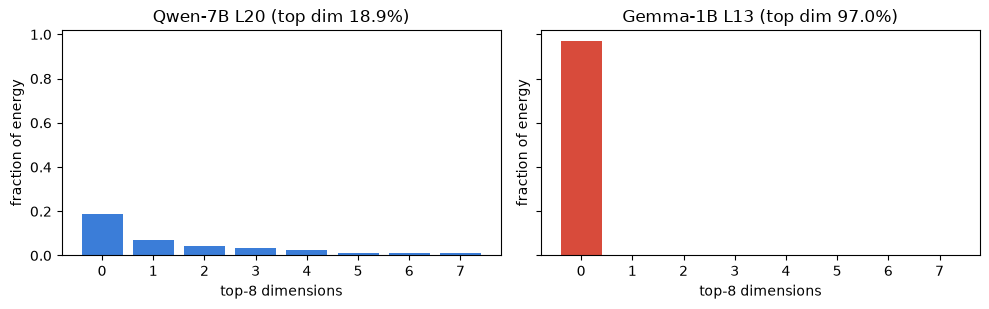

Qwen: energy spread across many dims -> cosine/normalize geometry works.
Gemma: one dim eats everything -> must center / drop-top-PC before reading.


In [11]:
import matplotlib.pyplot as plt
# real measured top-8 per-dimension energy fractions (this repo, 2026-07)
QWEN_L20  = [0.189, 0.072, 0.045, 0.035, 0.023, 0.013, 0.011, 0.010]
GEMMA_L13 = [0.970, 0.002, 0.001, 0.001, 0.0005, 0.0005, 0.0004, 0.0004]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
ax[0].bar(range(8), QWEN_L20, color="#3b7dd8");  ax[0].set_title("Qwen-7B L20 (top dim 18.9%)")
ax[1].bar(range(8), GEMMA_L13, color="#d84b3b"); ax[1].set_title("Gemma-1B L13 (top dim 97.0%)")
for a in ax: a.set_xlabel("top-8 dimensions"); a.set_ylabel("fraction of energy")
plt.tight_layout(); plt.show()
print("Qwen: energy spread across many dims -> cosine/normalize geometry works.")
print("Gemma: one dim eats everything -> must center / drop-top-PC before reading.")

## G · Triangulate against Anthropic's NLA (extension)

Two *independently trained* NLAs describing the same activation is the strongest trust check: agreement means the readout is a property of the **model**, not a habit of one adapter. Anthropic's `kitft/nla-qwen2.5-7b-L20-av` is a **full model** (not a LoRA), so loading it live is the heaviest thing in this workshop — best done by **precomputing** its readouts for your demo prompts offline and shipping a small JSON, then showing ours vs theirs side by side. Confirm their injection protocol (token + scale) against their model card before trusting a live run — it may differ from ours.

---
### ✅ Self-check
Section **F runs with no GPU** and must always show the two bar charts (Qwen spread, Gemma one spike). For the GPU sections, the sign of success is *differential*: the deviation/difference/wrong-layer readouts should read **differently** from the plain one, and NOISE should look visibly less grounded. If every cell returns the same text, injection isn't landing — back to NB2.

In [12]:
QWEN_L20  = [0.189, 0.072, 0.045, 0.035, 0.023, 0.013, 0.011, 0.010]
assert QWEN_L20[0] < 0.5 and 0.97 > 0.5, "energy-concentration data sanity"
print("self-check: Qwen top-dim", f"{QWEN_L20[0]:.0%}", "vs Gemma 97% — "
      "the contrast that explains the small-model failure \u2713")

self-check: Qwen top-dim 19% vs Gemma 97% — the contrast that explains the small-model failure ✓
